# An analysis of words to define them as easy medium or hard in hangman

## Initial Imports 
Importing Pandas for holding and modifying the data 
Declaring a dictionary for the most common letters in the english language
Declaring a list to get easy access to vowels in the English Language

In [4]:
import pandas as pd
import numpy as np
letterFrequency = {'E' : 12.0,
'T' : 9.10,
'A' : 8.12,
'O' : 7.68,
'I' : 7.31,
'N' : 6.95,
'S' : 6.28,
'R' : 6.02,
'H' : 5.92,
'D' : 4.32,
'L' : 3.98,
'U' : 2.88,
'C' : 2.71,
'M' : 2.61,
'F' : 2.30,
'Y' : 2.11,
'W' : 2.09,
'G' : 2.03,
'P' : 1.82,
'B' : 1.49,
'V' : 1.11,
'K' : 0.69,
'X' : 0.17,
'Q' : 0.11,
'J' : 0.10,
'Z' : 0.07 }
vowels = ['a', 'e', 'i', 'o', 'u', 'y']

## Opening the data and doing initial analysis
Open the data
Introduce a new column Words to make reading off the words more easy
Introduce a column for length to get the length of all the words in the dataset 
Introduce a new column for Frequency, the dataset has the most frequent words in English first 
- Invert the list so most frequent has the heighest value, then reduce it down by a weighting to make it applicable later on


In [6]:
words_df = pd.read_csv('google-10000-english-no-swears.txt', sep=' ', header=None)

In [8]:
words_df.head()
words_df['Words'] = words_df


In [10]:
words_df['length'] = words_df['Words'].str.len()

words_df.head()

,0,Words,length
0,the,the,3.0
1,of,of,2.0
2,and,and,3.0
3,to,to,2.0
4,a,a,1.0


In [12]:
words_df['Frequency'] = (len(words_df)- words_df.index+1)/2000

In [14]:
words_df.head()

,0,Words,length,Frequency
0,the,the,3.0,4.9475
1,of,of,2.0,4.9470
2,and,and,3.0,4.9465
3,to,to,2.0,4.9460
4,a,a,1.0,4.9455


## Main Data Modification
Creates an Array for Number of repeated letters, average letter frequencies and number of vowels as an array of zeros 
Loop through the data frame 
- Loop through the letters in each word
- If Letter already appeared add to the repeated letters
- Add the frequency of each letter to the total letter frequency
- If the letter is a vowel add one to the vowel counts
- Create an average of the total letter frequency
Add new columns to the dataframe for each of these variables

In [17]:
Repeats = np.zeros(len(words_df))
frequencies = np.zeros(len(words_df))
vowelCounts = np.zeros(len(words_df))
for i in words_df.index:
    LettersUsed = []
    totalfrequency = 0
    for j in str(words_df['Words'][i]):
        if j not in LettersUsed:
            LettersUsed.append(j)
        else:
            Repeats[i] = Repeats[i] + 1

        totalfrequency += letterFrequency[j.upper()]

        if j in vowels:
            vowelCounts[i] = vowelCounts[i] + 1
    averageFrequency = totalfrequency / len(str(words_df['Words'][i]))
    frequencies[i] = averageFrequency
words_df['Repeats'] = Repeats *1.1
words_df['AverageFrequency'] = frequencies * 1.2
words_df['VowelCounts'] = vowelCounts * 1.3

In [19]:
words_df.describe()

,length,Frequency,Repeats,AverageFrequency,VowelCounts
count,9893.000000,9894.000000,9894.000000,9894.000000,9894.000000
mean,6.596078,2.474250,1.058308,7.371937,3.343552
std,2.553906,1.428148,1.235421,1.454946,1.644149
min,1.000000,0.001000,0.000000,0.084000,0.000000
25%,5.000000,1.237625,0.000000,6.600429,2.600000
50%,6.000000,2.474250,1.100000,7.491514,2.600000
75%,8.000000,3.710875,2.200000,8.314169,3.900000
max,18.000000,4.947500,7.700000,14.400000,10.400000


## Import Basic plotting modules and doing basic plotting 

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

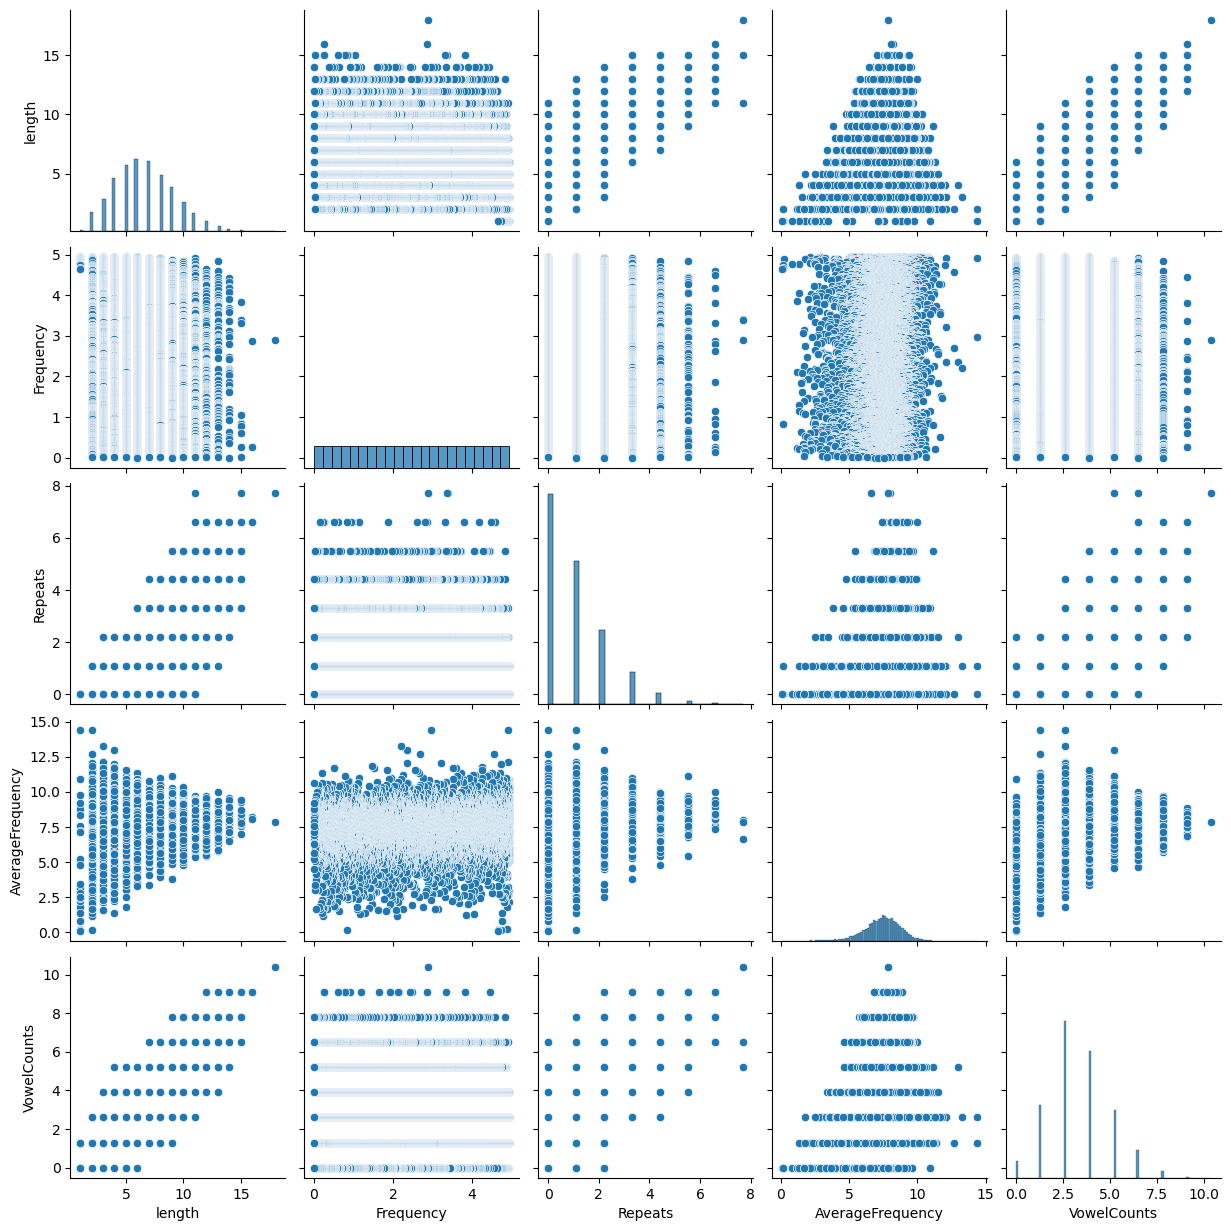

In [23]:
sns.pairplot(words_df)

## Import K Means Clustering for unsupervised machine learning 
Remove all rows where there is no value for an item 
Fit the model based on word length, frequency in english, repeats, average letter frequency and the number of vowels
Plot the output

In [27]:
from sklearn.cluster import KMeans


In [28]:
words_df.dropna(inplace=True)

In [31]:
kmeans = KMeans(n_clusters=3,max_iter=1000)
kmeans.fit(words_df[['length', 'Frequency', 'Repeats', 'AverageFrequency','VowelCounts']])

KMeans(max_iter=1000, n_clusters=3)

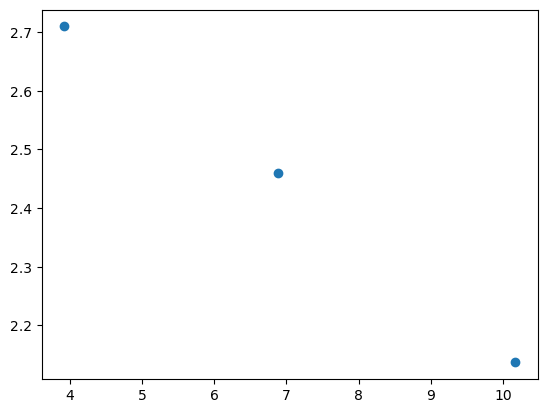

In [33]:
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1])

## Get the prediction from the machine learning model 
Get the prediction
Add it to the data frame
Add Difficulties to the dataframe based on the prediction 

In [36]:
words_df['Prediction'] = kmeans.predict(words_df[['length', 'Frequency', 'Repeats','AverageFrequency','VowelCounts']])

In [38]:
words_df.describe()

,length,Frequency,Repeats,AverageFrequency,VowelCounts,Prediction
count,9893.000000,9893.000000,9893.000000,9893.000000,9893.000000,9893.000000
mean,6.596078,2.474129,1.058304,7.371792,3.343758,1.230365
std,2.553906,1.428170,1.235483,1.454948,1.644103,0.781664
min,1.000000,0.001000,0.000000,0.084000,0.000000,0.000000
25%,5.000000,1.237500,0.000000,6.600000,2.600000,1.000000
50%,6.000000,2.474000,1.100000,7.491429,2.600000,1.000000
75%,8.000000,3.711000,2.200000,8.313818,3.900000,2.000000
max,18.000000,4.947500,7.700000,14.400000,10.400000,2.000000


In [40]:
Difficulties = []
for i in words_df['Prediction']:
    if i == 0:
        Difficulties.append('Easy')
    if i == 1:
        Difficulties.append('Hard')
    if i == 2:
        Difficulties.append('Medium')

words_df['Difficulty'] = Difficulties

In [42]:
words_df.head()

,0,Words,length,Frequency,Repeats,AverageFrequency,VowelCounts,Prediction,Difficulty
0,the,the,3.0,4.9475,0.0,10.808,1.3,1,Hard
1,of,of,2.0,4.9470,0.0,5.988,1.3,1,Hard
2,and,and,3.0,4.9465,0.0,7.756,1.3,1,Hard
3,to,to,2.0,4.9460,0.0,10.068,1.3,1,Hard
4,a,a,1.0,4.9455,0.0,9.744,1.3,1,Hard


## Final alterations and creating the file
Remove all words where the length is less than 2 
Add the words to a .txt file with the capitalised word followed by the difficulty

In [45]:
for i in words_df.index:
    if words_df['length'][i] <= 2:
        words_df.drop(i, inplace=True)

In [46]:
with open('Words.txt', 'w') as f:
    for i in words_df.index:
        word = str(words_df['Words'][i])
        f.write(word.capitalize() + " " + str(words_df['Difficulty'][i]) + "\n")